# Road Follower - Train Model

In this notebook we will train a neural network to take an input image, and output a set of x, y values corresponding to a target.

We will be using PyTorch deep learning framework to train ResNet18 neural network architecture model for road follower application.

In [1]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
import glob
import PIL.Image
import os
import numpy as np

### Create Dataset Instance

Here we create a custom ``torch.utils.data.Dataset`` implementation, which implements the ``__len__`` and ``__getitem__`` functions.  This class
is responsible for loading images and parsing the x, y values from the image filenames.  Because we implement the ``torch.utils.data.Dataset`` class,
we can use all of the torch data utilities :)

We hard coded some transformations (like color jitter) into our dataset.  We made random horizontal flips optional (in case you want to follow a non-symmetric path, like a road
where we need to 'stay right').  If it doesn't matter whether your robot follows some convention, you could enable flips to augment the dataset.

In [2]:
def get_x(path):
    """Gets the x value from the image filename"""
    return (float(int(path[3:6])) - 50.0) / 50.0

def get_y(path):
    """Gets the y value from the image filename"""
    return (float(int(path[7:10])) - 50.0) / 50.0

class XYDataset(torch.utils.data.Dataset):
    
    def __init__(self, directory, augment=False):
        self.directory = directory
        self.augment = augment
        self.image_paths = sorted(glob.glob(os.path.join(self.directory, '*.jpg')))
        self.color_jitter = transforms.ColorJitter(
            brightness=0.25,
            contrast=0.2,
            saturation=0.15,
            hue=0.02,
        )
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        
        image = PIL.Image.open(image_path)
        x = float(get_x(os.path.basename(image_path)))
        y = float(get_y(os.path.basename(image_path)))
        
        if self.augment and np.random.rand() > 0.5:
            image = transforms.functional.hflip(image)
            x = -x
        
        if self.augment:
            image = self.color_jitter(image)
        image = transforms.functional.resize(image, (224, 224))
        image = transforms.functional.to_tensor(image)
        image = image.numpy()[::-1].copy()
        image = torch.from_numpy(image)
        image = transforms.functional.normalize(image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        
        return image, torch.tensor([x, y]).float()
    
dataset = XYDataset('../../data/labelled', augment=True)

### Split dataset into train and test sets
Once we read dataset, we will split data set in train and test sets. In this example we split train and test a 90%-10%. The test set will be used to verify the accuracy of the model we train.

In [3]:
test_percent = 0.1
num_test = int(test_percent * len(dataset))
train_subset, test_subset = torch.utils.data.random_split(dataset, [len(dataset) - num_test, num_test])
train_dataset = torch.utils.data.Subset(XYDataset('../../data/labelled', augment=True), train_subset.indices)
test_dataset = torch.utils.data.Subset(XYDataset('../../data/labelled', augment=False), test_subset.indices)

In [4]:
len(dataset)

1407

### Create data loaders to load data in batches

We use ``DataLoader`` class to load data in batches, shuffle data and allow using multi-subprocesses. In this example we use batch size of 64. Batch size will be based on memory available with your GPU and it can impact accuracy of the model.

In [5]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

### visualise image from dataset with point

File : xy_043_055_161f857e-5226-11f1-ba21-811e3d289a12.jpg
x=-0.140, y=0.100  →  pixel (96, 123)


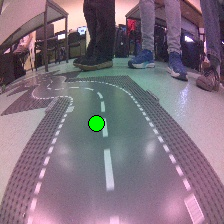

In [6]:
import random, glob, os
import PIL.Image
from IPython.display import display

def show_random_labeled_image(data_dir='../../data/labelled'):
    paths = glob.glob(os.path.join(data_dir, '*.jpg'))
    if not paths:
        print(f"No images found in {data_dir}")
        return

    path = random.choice(paths)
    name = os.path.basename(path)

    x = get_x(name)
    y = get_y(name)

    img = PIL.Image.open(path).resize((224, 224))
    draw = PIL.ImageDraw.Draw(img)

    # Convert normalized [-1,1] coords back to pixel coords
    px = int((x + 1) / 2 * 224)
    py = int((y + 1) / 2 * 224)

    draw.ellipse((px-8, py-8, px+8, py+8), fill=(0,255,0), outline=(0,0,0))

    print(f"File : {name}")
    print(f"x={x:.3f}, y={y:.3f}  →  pixel ({px}, {py})")
    display(img)

show_random_labeled_image()

### Define Neural Network Model 

We use ResNet-18 model available on PyTorch TorchVision. 

In a process called transfer learning, we can repurpose a pre-trained model (trained on millions of images) for a new task that has possibly much less data available.


More details on ResNet-18 : https://github.com/pytorch/vision/blob/master/torchvision/models/resnet.py

More Details on Transfer Learning: https://www.youtube.com/watch?v=yofjFQddwHE 

In [7]:
#model = models.resnet18(pretrained=True)
#model.fc = torch.nn.Linear(512, 2)


model = models.mobilenet_v3_small(pretrained=True)
model.classifier[-1] = torch.nn.Linear(1024, 2)

# model = models.mobilenet_v2(pretrained=True)
# model.classifier[-1] = torch.nn.Linear(1280, 2)

/home/stick/sem6/rob/jetbot_project/Jetbot/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/stick/sem6/rob/jetbot_project/Jetbot/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet model has fully connect (fc) final layer with 512 as ``in_features`` and we will be training for regression thus ``out_features`` as 1

Finally, we transfer our model for execution on the GPU

In [8]:
MODEL_NAME_MAP = {
    'ResNet': 'resnet18',
    'MobileNetV3': 'mobilenet_v3_small',
    'MobileNetV2': 'mobilenet_v2',
    'EfficientNet': 'efficientnet_b0',
}

In [9]:
# 


# model.fc = torch.nn.Sequential(
#     torch.nn.Linear(512, 128),
#     torch.nn.ReLU(),
#     torch.nn.Dropout(0.3),
#     torch.nn.Linear(128, 2)
# )
device = torch.device('cpu')
model = model.to(device)

### Train Regression:

We train for 50 epochs and save best model if the loss is reduced. 

In [10]:
NUM_EPOCHS = 50
BEST_MODEL_PATH = f'best_steering_model_xy_{model.__class__.__name__.lower()}.pth'
best_loss = 1e9
LEARNING_RATE = 0.0005  # Lower learning rate for transfer learning
MAX_GRAD_NORM = 1.0     # Gradient clipping threshold

In [19]:

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

for epoch in range(NUM_EPOCHS):
    
    model.train()
    train_loss = 0.0
    for images, labels in iter(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = F.mse_loss(outputs, labels)
        train_loss += float(loss)
        loss.backward()
        # Clip gradients to prevent large updates
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
    train_loss /= len(train_loader)
    
    model.eval()
    test_loss = 0.0
    for images, labels in iter(test_loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = F.mse_loss(outputs, labels)
        test_loss += float(loss)
    test_loss /= len(test_loader)
    
    # Step the scheduler based on test loss
    scheduler.step(test_loss)
    
    print('%f, %f' % (train_loss, test_loss))
    if test_loss < best_loss:
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        best_loss = test_loss

0.049356, 0.017037
0.014566, 0.018532
0.011071, 0.005039
0.007317, 0.002947
0.006676, 0.006261
0.005012, 0.002372
0.005607, 0.002647
0.004161, 0.001981
0.003326, 0.001836
0.002717, 0.001182
0.002637, 0.001618
0.003050, 0.001372
0.002574, 0.001882
0.001996, 0.001111
0.002000, 0.002038
0.002183, 0.001304
0.002053, 0.001083
0.001598, 0.001790
0.002100, 0.001153
0.001731, 0.001042
0.001549, 0.001150
0.001652, 0.001303
0.001309, 0.001201
0.001409, 0.001166
0.001076, 0.000952
0.001168, 0.000908
0.001125, 0.000951


KeyboardInterrupt: 

### load best model and save safely with onnx


In [11]:
# Load best weights back into the model
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

# Export to ONNX
dummy = torch.zeros((1, 3, 224, 224))
BEST_MODEL_PATH_ONNX = BEST_MODEL_PATH.replace('.pth', '.onnx')
torch.onnx.export(
    model,
    dummy,
    BEST_MODEL_PATH_ONNX,
    input_names=['input'],
    output_names=['output'],
    opset_version=11        # opset 11 is widely supported, including older onnxruntime
)
print(f"Saved ONNX model to {BEST_MODEL_PATH_ONNX}")

W0525 23:24:12.130000 78215 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/stick/sem6/rob/jetbot_project/Jetbot/venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/stick/sem6/rob/jetbot_project/Jetbot/venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/stick/sem6/rob/je

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved ONNX model to best_steering_model_xy_mobilenetv3.onnx


Once the model is trained, it will generate ``best_steering_model_xy.pth`` file which you can use for inferencing in the live demo notebook.

If you trained on a different machine other than JetBot, you'll need to upload this to the JetBot to the ``road_following`` example folder.

### Optimize Model with TensorRT (Optional)
Executing the code below will use `torch2trt` to create an optimized TensorRT engine. This process takes a few minutes but is required to reach high FPS (up to 60 FPS) on the Jetson Nano. 
Note: You only need to run this once or whenever you have a new trained model.

## Annotate with model

prep sys.path, src_dir= /home/stick/sem6/rob/jetbot_project/Jetbot/sakupen_circles/src/sakupen_circles/src
Launching interactive UI...


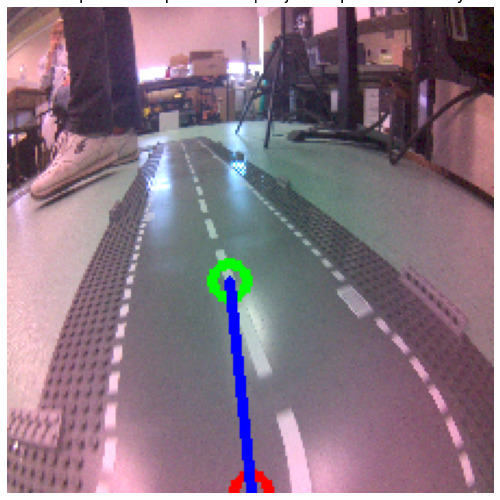

In [12]:
# Interactive demo: launch the prediction + labeling UI
# Ensure path contains the current notebook's src folder and ipympl is available
import sys, os
src_dir = os.path.abspath(os.path.join(os.getcwd(), 'sakupen_circles', 'src'))
# also try local folder (notebook's folder)
nb_dir = os.path.abspath(os.path.dirname(''))
sys.path.insert(0, src_dir)
sys.path.insert(0, os.path.abspath('.'))
print('prep sys.path, src_dir=', src_dir)
%matplotlib widget
try:
    import ipympl
except Exception as e:
    print('ipympl not available; run: pip install ipympl')
from interactive_predict_label import run_interactive
print('Launching interactive UI...')
# Use the BEST_MODEL_PATH saved earlier by this notebook
model_type = MODEL_NAME_MAP[model.__class__.__name__]

run_interactive(model_path=BEST_MODEL_PATH_ONNX, source_dir='../../data/dataset_images', output_dir='../../data/labelled', img_size=224, model_type=model_type)

In [ ]:
# import onnxruntime as ort
# import numpy as np
# import cv2

# def load_onnx_model(model_path):
#     sess = ort.InferenceSession(model_path)
#     input_name = sess.get_inputs()[0].name
#     output_name = sess.get_outputs()[0].name
#     print(f"Loaded ONNX model: {model_path}")
#     print(f"Input:  {sess.get_inputs()[0].name}  shape={sess.get_inputs()[0].shape}")
#     print(f"Output: {sess.get_outputs()[0].name} shape={sess.get_outputs()[0].shape}")
#     return sess, input_name, output_name


# def show_random_labeled_image(data_dir='../../data/labelled'):
#     paths = glob.glob(os.path.join(data_dir, '*.jpg'))
#     if not paths:
#         print(f"No images found in {data_dir}")
#         return

#     path = random.choice(paths)
#     name = os.path.basename(path)

#     x = get_x(name)
#     y = get_y(name)

#     img = PIL.Image.open(path).resize((224, 224))
#     draw = PIL.ImageDraw.Draw(img)

#     # Convert normalized [-1,1] coords back to pixel coords
#     px = int((x + 1) / 2 * 224)
#     py = int((y + 1) / 2 * 224)

#     draw.ellipse((px-8, py-8, px+8, py+8), fill=(0,255,0), outline=(0,0,0))

#     print(f"File : {name}")
#     print(f"x={x:.3f}, y={y:.3f}  →  pixel ({px}, {py})")
#     display(img)


# def predict_onnx(sess, input_name, output_name, image_bgr, img_size=224):
#     """Takes a BGR numpy image, returns (x, y) normalized to [-1, 1]."""
#     # Preprocess — same pipeline as training
#     img = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
#     img = cv2.resize(img, (img_size, img_size)).astype(np.float32) / 255.0

#     mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
#     std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
#     img = (img - mean) / std

#     # HWC -> NCHW (batch of 1)
#     img = img.transpose(2, 0, 1)[np.newaxis, ...]

#     xy = sess.run([output_name], {input_name: img})[0].flatten()
#     return float(np.clip(xy[0], -1, 1)), float(np.clip(xy[1], -1, 1))


# # --- Usage ---
# sess, input_name, output_name = load_onnx_model('best_steering_model_xy_mobilenetv3.onnx')

# # Single image test
# test_images = glob.glob(os.path.join('../../data/dataset_images', '*.png'))
# random_image = np.random.choice(test_images)
# print("random_image", random_image)
# img_bgr = cv2.imread(random_image)
# x, y = predict_onnx(sess, input_name, output_name, img_bgr)



Loaded ONNX model: best_steering_model_xy_mobilenetv3.onnx
Input:  input  shape=[1, 3, 224, 224]
Output: output shape=[1, 2]
random_image ../../data/dataset_images/1778600919.940783.png
x=-0.291, y=0.131
